# Importing Packages and Loading CSV Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df=pd.read_csv(r"Visadata.csv")
# Print shape of dataset
print(df.shape)

(25480, 12)


# Data Cleaning

# Handling Missing Values
- Handling Missing values
- Handling Duplicates
- Check Data type
- understand the dataset

**Check Null Values**

In [2]:
# these are the features with nan value
features_with_na = [features for features in df.columns if df[features].isnull().sum()>=1]
for features in features_with_na:
    print(features,np.round(df[features].isnull().mean()*100,5), '% missing values')
features_with_na

[]

- There are no null values in the dataset

# Other Data cleaning steps

**Handling Duplicates**

In [3]:
df.duplicated().sum()

0

- No Duplicates value in the dataset

**Remove case_id from the dataset as it cannot used in model Training**

In [4]:
df.drop('case_id', inplace=True, axis=1)

# Feature Engineering

## Feature Extraction

In [5]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
# Importing date class from datetime module
from datetime import date

# creating the date object of today's date
todays_date = date.today()
curent_year = todays_date.year

In [7]:
curent_year

2026

**Subtract current year wit year of establishment to get  company's age**

In [8]:
df['company_age'] = curent_year - df['yr_of_estab']

In [9]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [10]:
df.drop('yr_of_estab', inplace=True, axis=1)

## Types of Features

**Numeric Features**

In [11]:
num_features = [feature for feature in df.columns if df[feature].dtype!='O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 3


**Categorical Features**

In [12]:
cat_features = [feature for feature in df.columns if df[feature].dtype =='O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 8


**Discrete Features**

In [13]:
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print("Num of discrete features: ", len(discrete_features))

Num of discrete features:  0


**Continues Features**

In [14]:
continues_features = [feature for feature in num_features if feature not in discrete_features]
print('num of Continues features :', len(continues_features))

num of Continues features : 3


## Split X and Y
- Split Dataframe to X and Y
- Here we set a variable i.e, independent columns, and a variabl y i.e, dependent columns as the "Case_Status" column.

In [15]:
X = df.drop('case_status', axis=1)
y=df['case_status']

In [16]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

## Manual Encoding target column

In [17]:
# If target column has Denied it is encoded as 1 others as 0
y = np.where(y=='Denied', 1, 0)

In [18]:
y

array([1, 0, 1, ..., 0, 0, 0])

## Feature Transformation

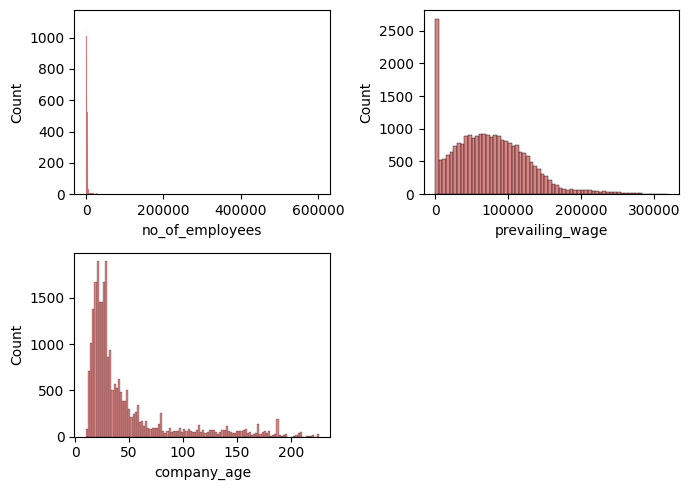

In [19]:
# distribution of data before scaling
plt.figure(figsize=(7,5))
for i, col in enumerate(['no_of_employees','prevailing_wage', 'company_age']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

- No of employees and company age column is skewed.
- Apply a power transformation featurewise to make data more Guassian-like.

Power tranforms are a family of paramatric, monotonic transformation that are applied to make data more Guassian-like. This is useful for modeling issue related to heteroscedasticity(non-constant variance), or other situations where normality is desired.

Currently, powerTransformrr supports the Box-Cox transform and the Yeo-Johnson transform.

**Checking Sskeweness**

**What is Skeweness**
- Skeweness refers to a distribution or asymmetry that deviates from the symmetrical bell curve, or normal distribution, In a set of data. If the Curve is shifted to the left or to the right, it is said to be skewed. Skeweness can be quantified as representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero.

In [20]:
# Check skewness
X[continues_features].skew(axis=0, skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

- Positively Skewed :company_age, no_of_emploees.
- We can handle outliers and then check the skewness.

## Apply Power Transformer to check if it can reduce the outliers

In [21]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])

In [22]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)

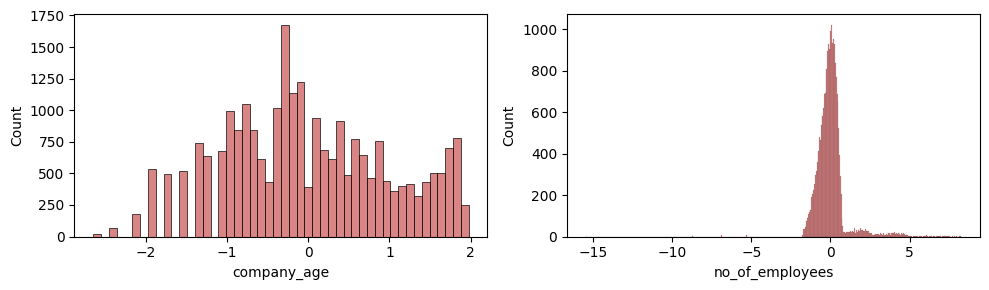

In [23]:
plt.figure(figsize=(10,3))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

**Checking Skeweness**

In [24]:
X_copy.skew(axis=0, skipna=True)

company_age        0.120823
no_of_employees    0.399339
dtype: float64

- Here Yeo-Johnson is used and it supports both possitive or negative data transformation.
- So Power Transformation with yeo-johnson can be used.

In [25]:
for feature in cat_features:
    print(feature, ':', df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


# Feature Encoding and Scalling
**Selecting number features for processing**

In [26]:
num_features = list(X.select_dtypes(exclude="object").columns)

In [27]:
num_features

['no_of_employees', 'prevailing_wage', 'company_age']

## Preprocessing using Column Transformer

In [28]:
# Create Column Transformer with 3 types of transformer
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_columns = ['continent','unit_of_wage','region_of_employment']
transform_columns = ['no_of_employees','prevailing_wage','company_age']

from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transform = StandardScaler()
oh_transform = OneHotEncoder()
ordinal_transform = OrdinalEncoder()
ordinal_encoder = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('transform', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transform,oh_columns),
        ("OrdinalEncoder", ordinal_encoder,or_columns),
        ("Transformer", transform_pipe,transform_columns),
        ("StandardScaler", numeric_transform,num_features)
    ]
)

In [29]:
X = preprocessor.fit_transform(X)
X

array([[ 0.        ,  1.        ,  0.        , ...,  0.38666657,
        -1.39853722, -0.65122993],
       [ 0.        ,  1.        ,  0.        , ..., -0.14228155,
         0.1698353 , -0.53321103],
       [ 0.        ,  1.        ,  0.        , ...,  1.69498375,
         0.91907852, -0.6748337 ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.19871259,
         1.36027953,  1.63833662],
       [ 0.        ,  1.        ,  0.        , ..., -0.16387483,
         0.22150859,  2.18122353],
       [ 0.        ,  1.        ,  0.        , ..., -0.10805575,
        -0.06776315,  0.45814768]])

# Classification

In [30]:
from imblearn.combine import SMOTETomek, SMOTEENN

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state = 42, sampling_strategy='minority' )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X,y)

## Train Test Split
- The train test split procedure is used to estimate the performance of machine learning algorithms when they are used to make prediction on data not used to train the model.
- It is fast and easy procedure to perform, the result of which allow you to compare the performance of machine learning algorithm.

In [31]:
from sklearn.model_selection import train_test_split
# Seperate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((13754, 25), (3439, 25))

In [32]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    ConfusionMatrixDisplay, 
    precision_score,
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [33]:
def evaluate_clf( true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1 score
    precission = precision_score(true, predicted) # Calculate Precission
    recall = recall_score(true, predicted) # Calculate recall 
    roc_auc = roc_auc_score(true, predicted) # Calculate ROC
    return acc, f1, precission, recall, roc_auc

In [34]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decission Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K- Neighbour Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "Support Vector Machine": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [35]:
# Create a function which can evaluate models and return a report
def evaluate_models(X,y, models):
    '''
    This function takes X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: The DataFrame which contains report of all models metrics with cost
    '''

    # Seperate Dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models_list = []
    accuracy_list = []
    auc = []

    for i in range (len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train Model

        # Make Prediction
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training Set Performance
        model_train_accuracy, model_train_f1, model_train_precision,\
        model_train_recall, model_train_rocauc_score=evaluate_clf(y_train, y_train_pred)

        # Test Set Performance
        model_test_accuracy, model_test_f1, model_test_precision,\
        model_test_recall, model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model Performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print("- F1 Score: {:.4f}".format(model_train_f1))
        print("- Precision: {:.4f}".format(model_train_precision))
        print("- Recall: {:.4f}".format(model_train_recall))
        print("- Roc Auc Score: {:.4f}".format(model_train_rocauc_score))

        print('----------------------------------------')

        print('Model Performance for Test set')
        print("- Accuracy: {:.4f}".format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print("- F1 Score: {:.4f}".format(model_test_f1))
        print("- Precision: {:.4f}".format(model_test_precision))
        print("- Recall: {:.4f}".format(model_test_recall))
        print("- Roc Auc Score: {:.4f}".format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')

    report = pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model name', 'Accuracy']).sort_values(by = 'Accuracy', ascending=False)

    return report    

In [36]:
base_model_report = evaluate_models(X=X_res, y=y_res, models = models)


Random Forest
Model Performance for Training set
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model Performance for Test set
- Accuracy: 0.9424
- F1 Score: 0.9477
- Precision: 0.9432
- Recall: 0.9522
- Roc Auc Score: 0.9414


Decission Tree
Model Performance for Training set
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model Performance for Test set
- Accuracy: 0.9136
- F1 Score: 0.9214
- Precision: 0.9187
- Recall: 0.9241
- Roc Auc Score: 0.9125


Gradient Boosting
Model Performance for Training set
- Accuracy: 0.8912
- F1 Score: 0.8990
- Precision: 0.9077
- Recall: 0.8904
- Roc Auc Score: 0.8913
----------------------------------------
Model Performance for Test set
- Accuracy: 0.8723
- F1 Score: 0.8824
- Precision: 0.8908
- Recall: 0.8742
- Roc Auc Score: 0.8722


Logistic Regression
Model Perfor

## *Result of all Models*

In [37]:
base_model_report

,Model name,Accuracy
0,Random Forest,0.942425
4,K- Neighbour Classifier,0.932829
5,XGBClassifier,0.918872
6,CatBoosting Classifier,0.916255
1,Decission Tree,0.913638
2,Gradient Boosting,0.872347
8,AdaBoost Classifier,0.855190
7,Support Vector Machine,0.835708
3,Logistic Regression,0.729863


## Here we can use Random Forest for Hyper Parameter Tuning

**Define the parameter distribution for random Forest** 

In [38]:
# Initialize few parameter for HyperParameter tuning
xgboost_params = {
    'max_depth': range(3,10,2),     #range(start, stop, step)
    'min_child_weight':range(1,6,2)
}

rf_params = {
    "max_depth":[10,12, None, 15,20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree','kd_tree', 'brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9]
}

In [39]:
# Models list for hyperParameter tuning
randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

**Create a function for Model Training and report which can be used in hyperparameter tuning loop**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions = params,
                                n_iter=100,
                                cv=3,
                                verbose=2,
                                n_jobs=-1)
    random.fit(X_res, y_res)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} ----------------")
    print(model_param[model_name])


Fitting 3 folds for each of 12 candidates, totalling 36 fits


Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits


In [ ]:
model_param

{'XGBoost': {'min_child_weight': 1, 'max_depth': 9},
 'RF': {'n_estimators': 200, 'max_features': 'log2', 'max_depth': None},
 'KNN': {'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}}

**Retarining the model with best Parameter**

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
best_models = {
    "Random Forest Classifier": RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier": KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier": XGBClassifier(**model_param['XGBoost'], n_jobs=-1)
}
tuned_report = evaluate_models(X=X_res, y=y_res, models=best_models)

Random Forest Classifier
Model Performance for Training set
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model Performance for Test set
- Accuracy: 0.9404
- F1 Score: 0.9460
- Precision: 0.9398
- Recall: 0.9522
- Roc Auc Score: 0.9391


KNeighborsClassifier
Model Performance for Training set
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model Performance for Test set
- Accuracy: 0.9654
- F1 Score: 0.9689
- Precision: 0.9533
- Recall: 0.9851
- Roc Auc Score: 0.9633


XGBClassifier
Model Performance for Training set
- Accuracy: 0.9992
- F1 Score: 0.9993
- Precision: 0.9987
- Recall: 0.9999
- Roc Auc Score: 0.9991
----------------------------------------
Model Performance for Test set
- Accuracy: 0.9343
- F1 Score: 0.9400
- Precision: 0.9400
- Recall: 0.9400
- Roc Auc Score: 0.9337




In [ ]:
tuned_report

,Model name,Accuracy
1,KNeighborsClassifier,0.965397
0,Random Forest Classifier,0.940390
2,XGBClassifier,0.934283


In [ ]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("Final MODEL 'KNN'")
print("Accuracy Score Value: {:.4f}".format(score))
print(cr)

Final MODEL 'KNN'
Accuracy Score Value: 0.9654
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1555
           1       0.95      0.99      0.97      1884

    accuracy                           0.97      3439
   macro avg       0.97      0.96      0.96      3439
weighted avg       0.97      0.97      0.97      3439



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)